# TAXI DRIVER DATA SET 


LINK :https://www.kaggle.com/datasets/dhruvdre5/new-york-city-taxi-and-limousine-commission-data



### _Loading and simple preview for the data:_

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data= pd.read_csv('C:/FCDS/3rd/FCDS-3rd-Term/DS_methodlgy/ProjectTaxidriver/2017_Yellow_Taxi_Trip_Data.csv')
df = pd.DataFrame(data)

print("Dataset Preview:\n", df.head())

Dataset Preview:
    Unnamed: 0  VendorID    tpep_pickup_datetime   tpep_dropoff_datetime  \
0    24870114         2   03/25/2017 8:55:43 AM   03/25/2017 9:09:47 AM   
1    35634249         1   04/11/2017 2:53:28 PM   04/11/2017 3:19:58 PM   
2   106203690         1   12/15/2017 7:26:56 AM   12/15/2017 7:34:08 AM   
3    38942136         2   05/07/2017 1:17:59 PM   05/07/2017 1:48:14 PM   
4    30841670         2  04/15/2017 11:32:20 PM  04/15/2017 11:49:03 PM   

   passenger_count  trip_distance  RatecodeID store_and_fwd_flag  \
0                6           3.34           1                  N   
1                1           1.80           1                  N   
2                1           1.00           1                  N   
3                1           3.70           1                  N   
4                1           4.37           1                  N   

   PULocationID  DOLocationID  payment_type  fare_amount  extra  mta_tax  \
0           100           231             1   

### _Data Exploration:_


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null 

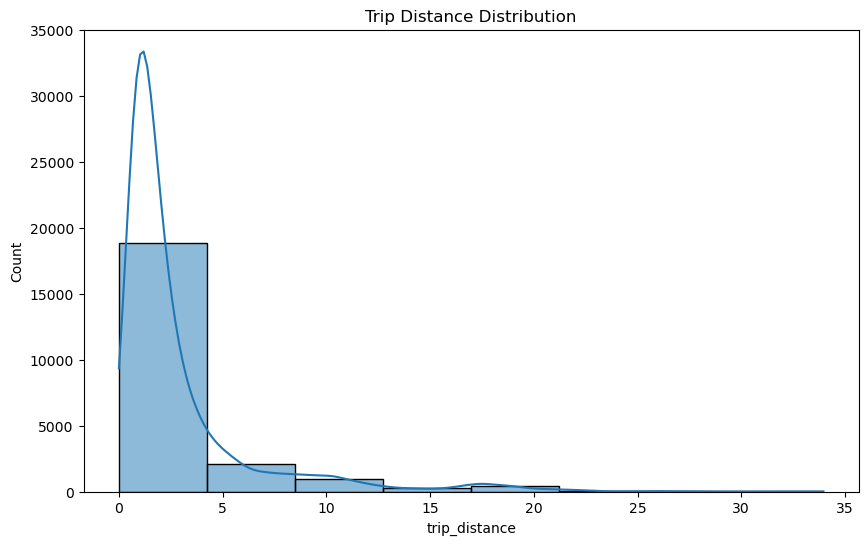

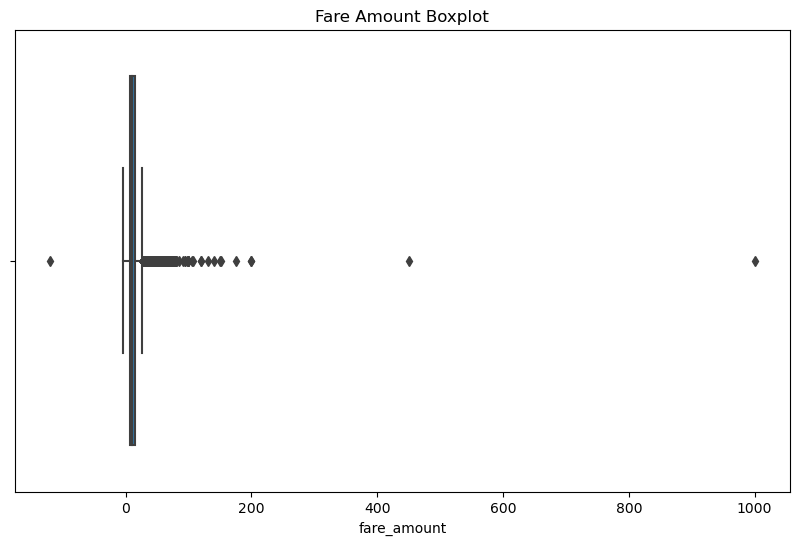

In [ ]:
print("\nDataset Info:\n")
df.info()
print("\nSummary Statistics:\n", df.describe(include='all'))
print("\nMissing Values:\n", df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.histplot(df["trip_distance"], kde=True, bins=8)
plt.title("Trip Distance Distribution")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df["fare_amount"])
plt.title("Fare Amount Boxplot")
plt.show()


### _Data cleaning:_

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())


df.drop_duplicates(inplace=True)

fare_q1 = df["fare_amount"].quantile(0.25)
fare_q3 = df["fare_amount"].quantile(0.75)
fare_iqr = fare_q3 - fare_q1
fare_lower_bound = fare_q1 - 1.5 * fare_iqr
fare_upper_bound = fare_q3 + 1.5 * fare_iqr

df = df[(df["fare_amount"] >= fare_lower_bound) & (df["fare_amount"] <= fare_upper_bound)]

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df = df[df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"]]


Missing values before cleaning:
Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64


### _Data Analysis:_

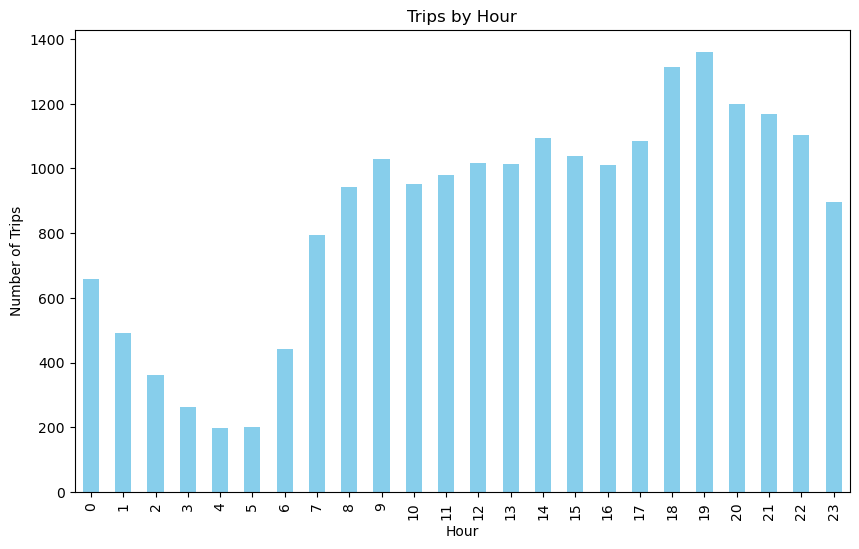

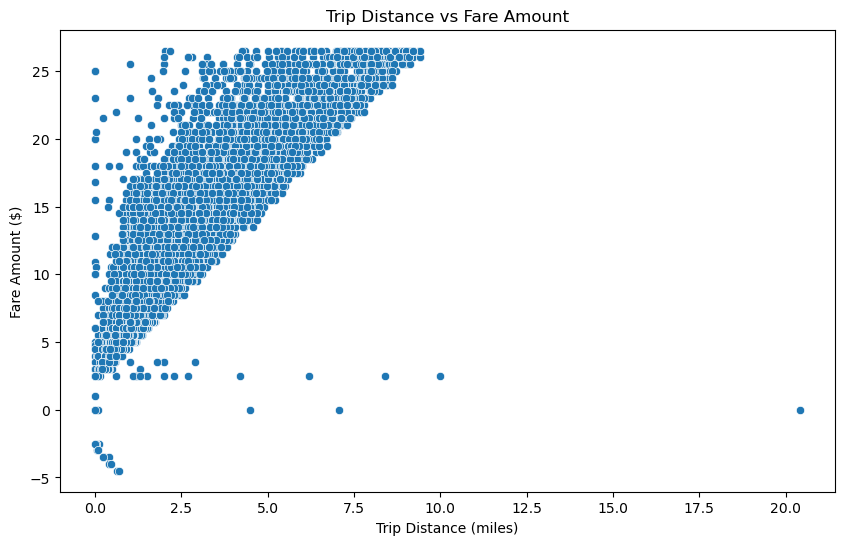

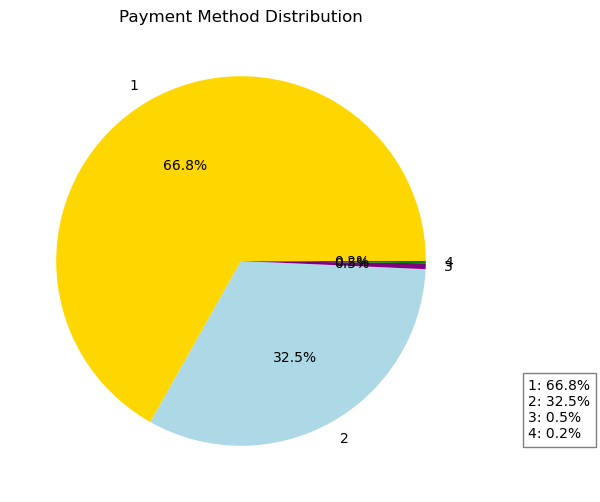

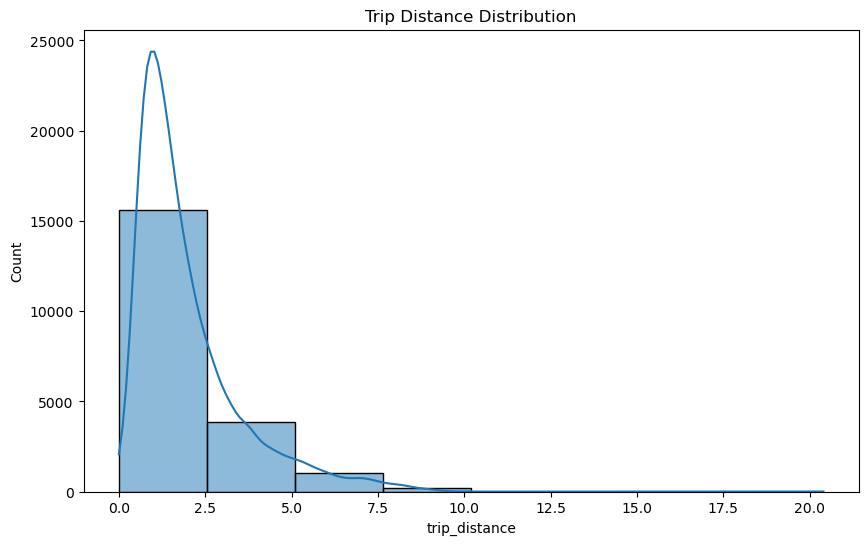

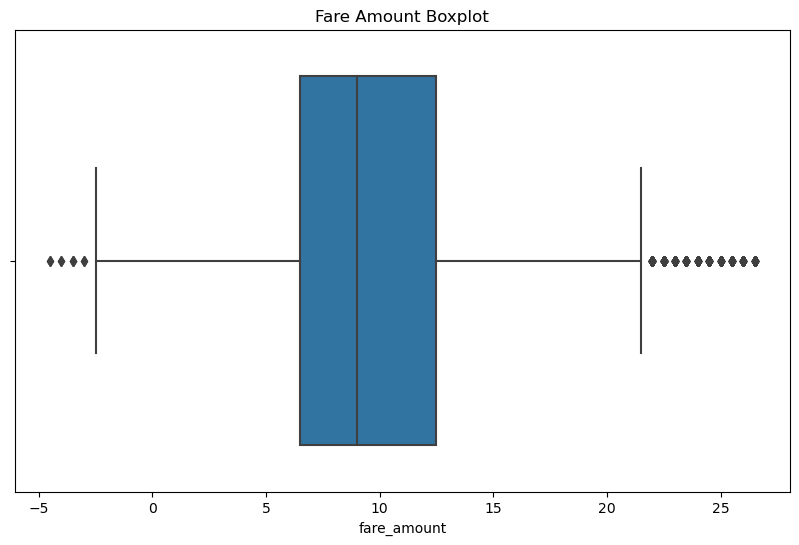

In [ ]:
peak_hours = df["tpep_pickup_datetime"].dt.hour.value_counts().sort_index()
plt.figure(figsize=(10, 6))
peak_hours.plot(kind="bar", color="skyblue")
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x="trip_distance", y="fare_amount", data=df)
plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.show()

payment_counts = df["payment_type"].value_counts()
percentages = (payment_counts / payment_counts.sum()) * 100
labels = [f"{method}: {percent:.1f}%" for method, percent in zip(payment_counts.index, percentages)]
plt.figure(figsize=(10, 6))
payment_counts.plot(kind="pie", autopct="%1.1f%%", colors=["gold", "lightblue", "purple" , "green"])
plt.title("Payment Method Distribution")
plt.ylabel("")
text = "\n".join(labels)
plt.gcf().text(0.8, 0.2, text, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()


plt.figure(figsize=(10, 6))
sns.histplot(df["trip_distance"], kde=True, bins=8)
plt.title("Trip Distance Distribution")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df["fare_amount"])
plt.title("Fare Amount Boxplot")
plt.show()

### _Summary / Report:_

In [44]:
print("\nInsights Derived:")
print("- Peak hours for taxi trips are:", peak_hours.idxmax(), "o'clock.")
print("- There is a general trend showing higher fares for longer trips, with some exceptions.")
print("- Most trips are paid using:", payment_counts.idxmax(), ".")


Insights Derived:
- Peak hours for taxi trips are: 19 o'clock.
- There is a general trend showing higher fares for longer trips, with some exceptions.
- Most trips are paid using: 1 .
